<br>

## **<span style="color:black"> 1. Problem statement  </span>** 

Early detection of diabetes is crucial for patient health management. Medical diagnostic data 
contains complex patterns that can indicate a patient's risk. This project aims to develop and 
compare two supervised learning models, Logistic Regression and Linear Discriminant 
Analysis (LDA), to accurately predict whether a patient has diabetes based on this diagnostic 
data. 

<br>

## **<span style="color:black"> 2. Libraries  </span>** 

In [1]:
## basic Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay,precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from sklearn.metrics import auc

from sklearn.model_selection import GridSearchCV


import warnings
warnings.filterwarnings('ignore')

<br>

## **<span style="color:black"> 3. Data Collection  </span>** 

In [3]:
df = pd.read_csv('diabetes.csv') 

print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<br>

## **<span style="color:black"> 4. Data Exploration  </span>** 


###### **i. Shape & Category**

In [4]:
## Shape of the Dataset
print('Dataset shape :', df.shape)

## get all the numeric features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Number of Numerical Features :', len(num_features))

##categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Number of Categorical Features :', len(cat_features))

## Discrete features
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Number of Discrete Features :',len(discrete_features))

## Continuous features
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Number of Continuous Features :',len(continuous_features))

Dataset shape : (768, 9)
Number of Numerical Features : 9
Number of Categorical Features : 0
Number of Discrete Features : 2
Number of Continuous Features : 7


###### **ii. Info**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


###### **iii. describe**

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Insight
- The dataset consists of **768** observations and **9** features, all of which are numerical.

- There are **no categorical features**, so no encoding is required.

- Among the **numerical features**:
    2 are discrete (Pregnancies, Outcome)
    7 are continuous, representing physiological and demographic measurements.

- All columns have 768 non-null values, indicating no missing values at the data-type level.

- The dataset has a small memory footprint (54.1 KB), making it efficient for analysis and model training.

- **The target variable** Outcome is binary:
    Mean value ≈ 0.35, indicating that about 35% of the individuals are diabetic and 65% are non-diabetic.
    This shows a moderate class imbalance.

- **Glucose** has a relatively high mean (~121) and large spread, making it an important feature for diabetes prediction.

- **BMI** has an average value of ~32, suggesting that most individuals fall in the overweight category, which is a known risk factor for diabetes.

- **Insulin** shows very high variability and extreme maximum values, indicating the presence of outliers.

- Several features (Glucose, BloodPressure, SkinThickness, Insulin, BMI) have minimum values of zero, which are physiologically unrealistic and likely represent missing or unrecorded measurements.

- **Age** ranges from 21 to 81 years, with most individuals being young to middle-aged adults.

- **Diabetes Pedigree Function** has a low mean but a wide range, reflecting varying levels of genetic predisposition.

- Overall, the dataset is suitable for **binary classification problems**, but it requires data cleaning, handling of zero values, and feature scaling before applying machine learning models.

<br>

## **<span style="color:black"> 5. Data Cleaning  </span>** 


<br>

###### **i. Duplicates**

In [7]:
df.duplicated().sum()

np.int64(0)

There are no Duplicate values in the dataset.

<br>

## **<span style="color:black"> 6. Featuree Engineering  </span>** 


<br>

###### **ii. Identify Invalid Zero Values**

I am checking this because Medical features cannot be zero physiologically:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

In [8]:
invalid_zero_features = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

(df[invalid_zero_features] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Handle: I will handle it by replacing Zero Values with Median!.

- Median is chosen because: robust to outliers (especially Insulin)

In [9]:
for feature in invalid_zero_features:
    median_value = df[feature].median()
    df[feature] = df[feature].replace(0, median_value)

In [10]:
# confirm preprocessing worked correctly.
(df[invalid_zero_features] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

<br>

## **<span style="color:black"> 7. EDA (Visualization)  </span>** 


In [11]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


<br>

##### **i. Feature Wise Visualization**

<br>

###### **I. Check Class Distribution (Target Variable)**

In [12]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

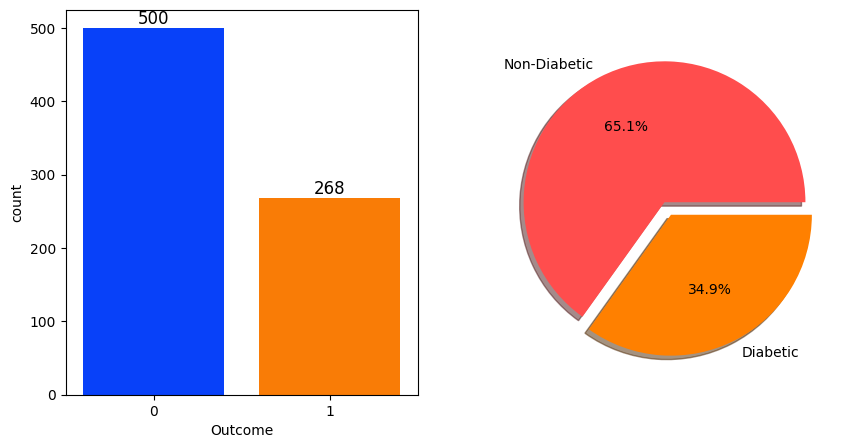

In [13]:
f,ax=plt.subplots(1,2,figsize=(10,5)) 
sns.countplot(x=df['Outcome'],data=df,palette ='bright',ax=ax[0], saturation=0.95) 
for container in ax[0].containers: 
    ax[0].bar_label(container,color='black',size=12) 
     
 
plt.pie(x=df['Outcome'].value_counts(),labels=['Non-Diabetic','Diabetic'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000']) 
plt.show() 

Insight:

The Dataset is slightly imbalance
 - Diabetic: : 268 people i.e 34.9% of people from our Dataset
 - Non-Diabetic: 500 people i.e 65.1% of people from our Dataset

<br>

###### **II. Age Feature**

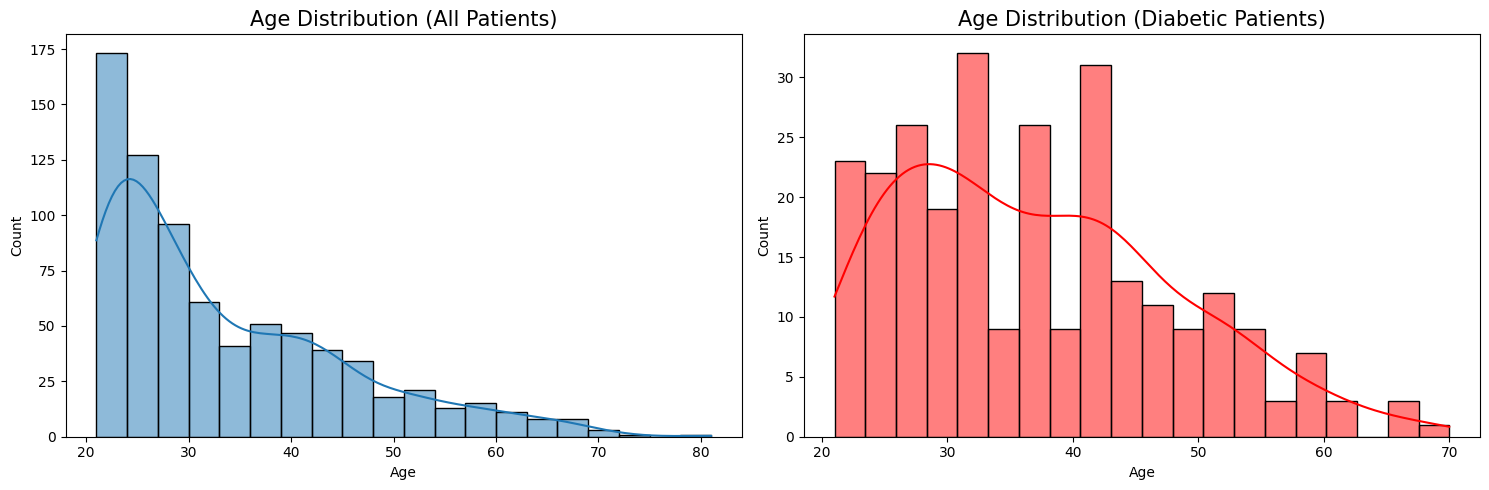

In [14]:
plt.rcParams['figure.figsize'] = (15, 5)

# 1. Age Distribution (All Patients)
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', bins=20, kde=True)
plt.title('Age Distribution (All Patients)', fontsize=15)

# 2. Age Distribution (Diabetic Patients)
plt.subplot(1, 2, 2)
sns.histplot(data=df[df['Outcome'] == 1], x='Age', bins=20, kde=True, color='red')
plt.title('Age Distribution (Diabetic Patients)', fontsize=15)

plt.tight_layout()
plt.show()


Insight:

**Age Distribution (All Patients)**

- The overall age distribution is right-skewed, with most patients concentrated between 21 and 35 years.
- The number of patients gradually decreases with increasing age, indicating fewer older individuals in the dataset.

**Age Distribution (Diabetic Patients)**

- Among diabetic patients, the age distribution is more spread out and shifted toward middle-aged and older groups.
- Diabetes prevalence appears higher in the age range of 30–50 years compared to younger ages.
- This suggests that age is an important risk factor, with the likelihood of diabetes increasing as age increases.

<br>

###### **III. Pregnancies Feature**

In [15]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


In [16]:
df['Pregnancies'].unique()

array([ 6,  1,  8,  0,  5,  3, 10,  2,  4,  7,  9, 11, 13, 15, 17, 12, 14])

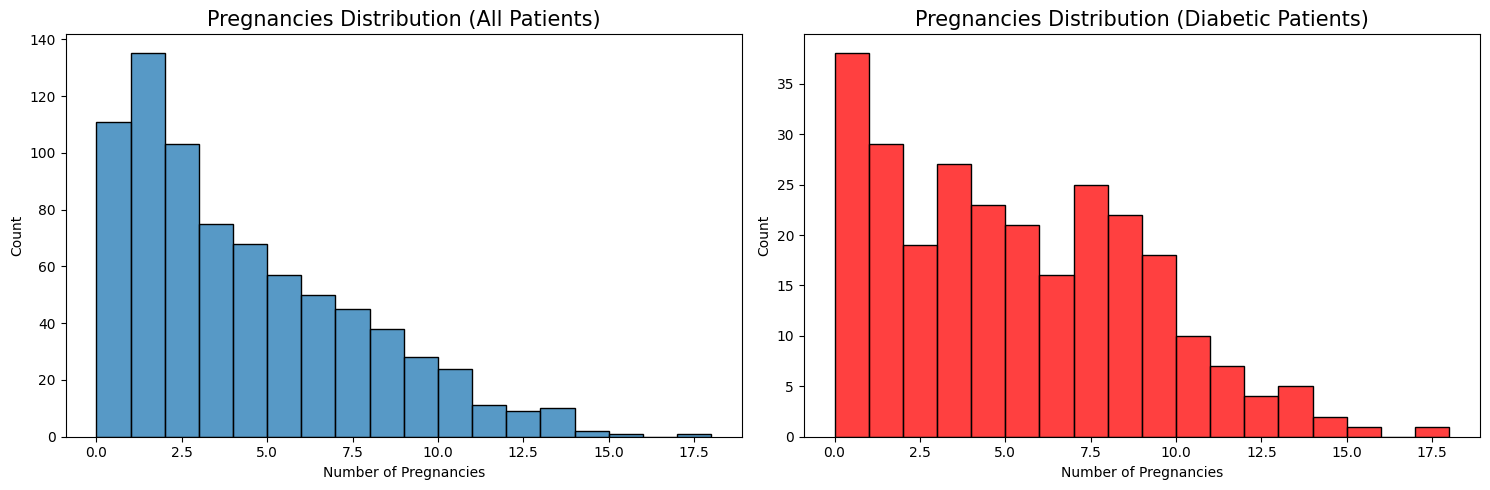

In [17]:
plt.rcParams['figure.figsize'] = (15, 5)

# 1. Pregnancies Distribution (All Patients)
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Pregnancies', bins=range(0, 19))
plt.title('Pregnancies Distribution (All Patients)', fontsize=15)
plt.xlabel('Number of Pregnancies')
plt.ylabel('Count')

# 2. Pregnancies Distribution (Diabetic Patients)
plt.subplot(1, 2, 2)
sns.histplot(data=df[df['Outcome'] == 1], x='Pregnancies', bins=range(0, 19), color='red')
plt.title('Pregnancies Distribution (Diabetic Patients)', fontsize=15)
plt.xlabel('Number of Pregnancies')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


Insight:

**Pregnancies Distribution (All Patients)**

- Most women in the dataset have 0 to 3 pregnancies, indicating a higher concentration at lower pregnancy counts.
- The distribution is right-skewed, with the frequency decreasing as the number of pregnancies increases.

**Pregnancies Distribution (Diabetic Patients)**

- Among diabetic patients, higher pregnancy counts (around 3–8 pregnancies) appear more frequently compared to the overall population.
- Very high pregnancy counts (>10) are rare but are more visible in the diabetic group.
- This suggests that a higher number of pregnancies may be associated with increased diabetes risk, making Pregnancies an important predictive feature.

<br>

##### **ii. CHECKING OUTLIERS**

In [18]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


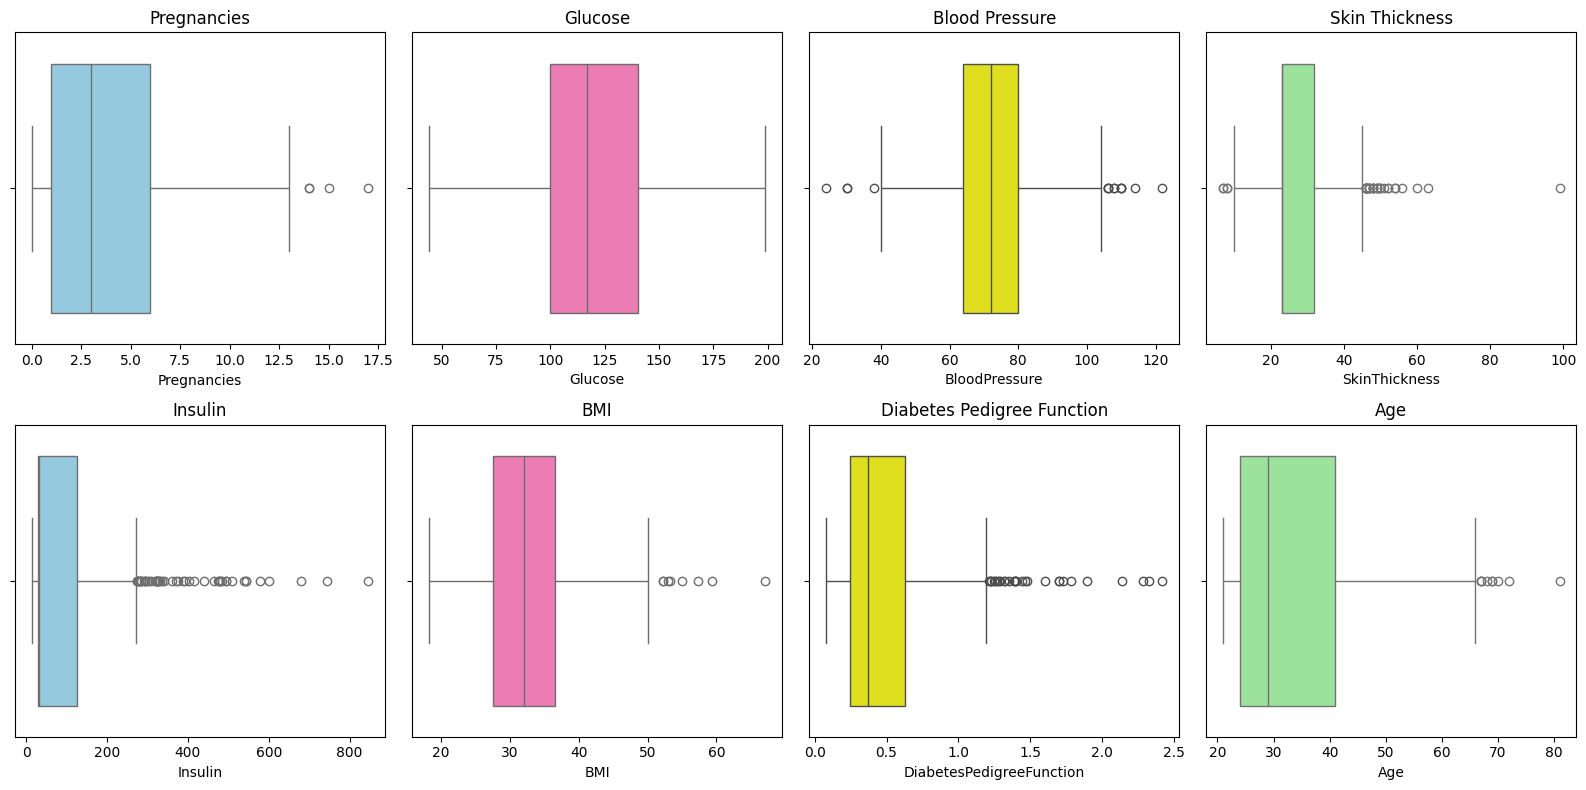

In [19]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
sns.boxplot(x=df['Pregnancies'], color='skyblue')
plt.title('Pregnancies')

plt.subplot(2, 4, 2)
sns.boxplot(x=df['Glucose'], color='hotpink')
plt.title('Glucose')

plt.subplot(2, 4, 3)
sns.boxplot(x=df['BloodPressure'], color='yellow')
plt.title('Blood Pressure')

plt.subplot(2, 4, 4)
sns.boxplot(x=df['SkinThickness'], color='lightgreen')
plt.title('Skin Thickness')

plt.subplot(2, 4, 5)
sns.boxplot(x=df['Insulin'], color='skyblue')
plt.title('Insulin')

plt.subplot(2, 4, 6)
sns.boxplot(x=df['BMI'], color='hotpink')
plt.title('BMI')

plt.subplot(2, 4, 7)
sns.boxplot(x=df['DiabetesPedigreeFunction'], color='yellow')
plt.title('Diabetes Pedigree Function')

plt.subplot(2, 4, 8)
sns.boxplot(x=df['Age'], color='lightgreen')
plt.title('Age')

plt.tight_layout()
plt.show()


Insight:

Genuine extreme values

- Glucose
- BloodPressure
- BMI
- Age
- Pregnancies

These extreme values are clinically possible
(e.g., high glucose, high BMI, older age, many pregnancies)

**I will not** remove these outliers


Rest I have already handled Large number of zeros with Median!, as these are data quality issues, not real outliers.

<br>

##### **iii. Correlation Heatmap**

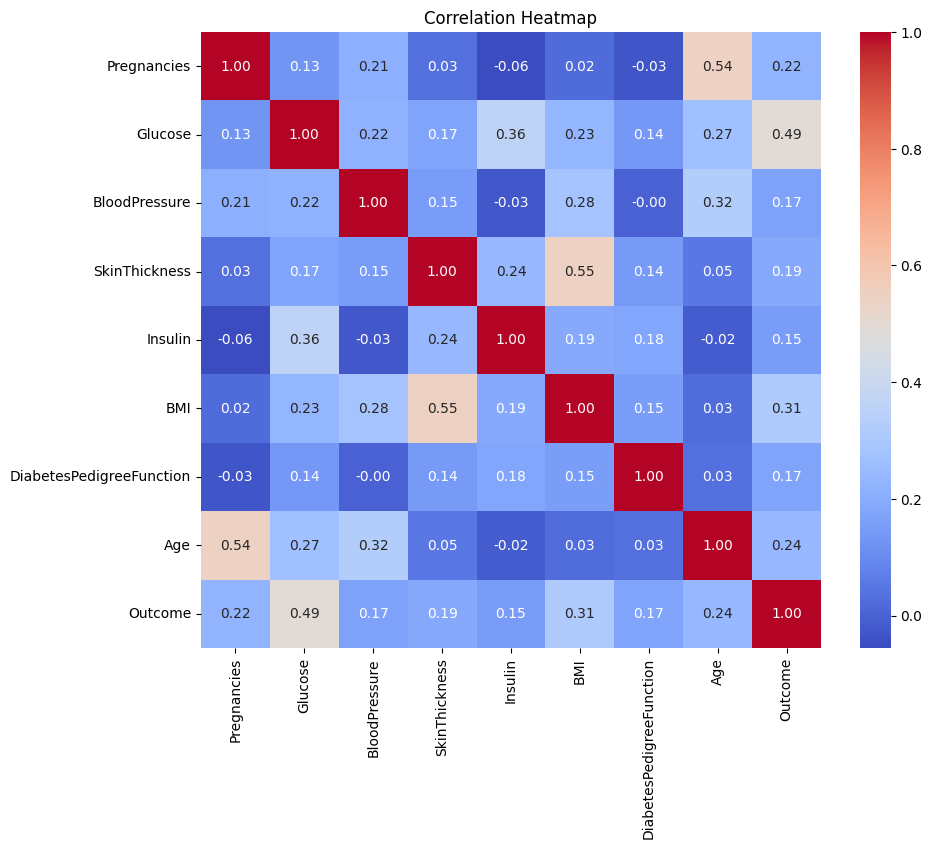

In [20]:
corr = df[
    ['Pregnancies','Glucose','BloodPressure','SkinThickness',
     'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


Insight:

Glucose, BMI, Age, and Pregnancies appear most relevant for predicting diabetes.

Other features like **Insulin**, **BloodPressure**, **DiabetesPedigreeFunction** and **SkinThickness** may provide additional value but have low correlations (<0.2) with Outcome, suggesting weak linear relationships.

NOTE: It will not Don’t drop these features purely based on correlation; Low correlation does not imply low predictive importance, especially when features interact. Therefore, i will use **model-based feature selection techniques** are more appropriate than correlation-based dropping.

If you find this notebook useful, please upvote it :)

<br>

## **<span style="color:black"> 8. ML Part  </span>** 


###### **i. I/P and O/P**

In [21]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

<br>

###### **ii. Dividing the Data**

In [22]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((614, 8), (154, 8))

<br>

###### **iii. Preprocessing**

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
pd.DataFrame(X_train_scaled)

,0,1,2,3,4,5,6,7
0,-0.526397,-1.256881,-0.018995,-0.454871,-0.612697,-0.050247,-0.490735,-1.035940
1,1.588046,-0.326051,0.808174,-0.340921,-0.612697,-0.598590,2.415030,1.487101
2,-0.828460,0.571536,-2.169636,-0.910670,-0.120429,-0.526439,0.549161,-0.948939
3,-1.130523,1.302903,-1.838768,-0.454871,-0.612697,-1.507685,-0.639291,2.792122
4,0.681856,0.405316,0.642740,1.140426,2.570636,1.998825,-0.686829,1.139095
...,...,...,...,...,...,...,...,...
609,0.379793,0.571536,-0.680731,0.912526,0.414033,-0.540870,-0.172824,-0.600933
610,-0.828460,-0.857954,4.116852,-0.454871,-0.612697,-1.435535,-0.778934,-0.513932
611,1.890109,-0.691734,1.139042,1.140426,-0.612697,1.912244,1.981245,0.443084
612,-1.130523,0.638024,-0.018995,-0.454871,-0.612697,1.450482,-0.784877,-0.339929


<br>

###### **iv. Model training & Model Selection**

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear Discriminant Analysis (LDA)": LinearDiscriminantAnalysis()
}

In [26]:
# =======================
# Model Evaluation Loop 
# =======================

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scaled, y_train)  # Train model

    # ===============================
    # Predictions
    # ===============================
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Get probability scores for ROC-AUC
    y_train_proba = model.predict_proba(X_train_scaled)[:, 1]   
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]     

    # ===============================
    # Training set performance
    # ===============================
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train, y_train_proba)        # ROC-AUC must use probabilities

    # ===============================
    # Test set performance
    # ===============================
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test, y_test_proba)           # ROC-AUC must use probabilities


    # ===============================
    # Output
    # ===============================
    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    print('=' * 35)
    print('\n')


Logistic Regression
Model performance for Training set
- Accuracy: 0.7687
- F1 score: 0.7610
- Precision: 0.7126
- Recall: 0.5587
- Roc Auc Score: 0.8485
----------------------------------
Model performance for Test set
- Accuracy: 0.7662
- F1 score: 0.7652
- Precision: 0.6792
- Recall: 0.6545
- Roc Auc Score: 0.8197


Linear Discriminant Analysis (LDA)
Model performance for Training set
- Accuracy: 0.7687
- F1 score: 0.7606
- Precision: 0.7152
- Recall: 0.5540
- Roc Auc Score: 0.8487
----------------------------------
Model performance for Test set
- Accuracy: 0.7727
- F1 score: 0.7701
- Precision: 0.7000
- Recall: 0.6364
- Roc Auc Score: 0.8180




<br>

###### **v. Feature Importance (Logistic Regression)**

In [27]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

feature_importance

,Feature,Coefficient
1,Glucose,1.138214
5,BMI,0.718367
7,Age,0.378817
0,Pregnancies,0.218415
6,DiabetesPedigreeFunction,0.216745
3,SkinThickness,0.049443
2,BloodPressure,-0.165564
4,Insulin,-0.224917


I Will drop **SkinThickness** feature

because

- Very small coefficient
- Weak standalone predictive power

<br>

In [28]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Drop least important features manually
X_train_selected = X_train.drop(['SkinThickness'], axis=1)
X_test_selected = X_test.drop(['SkinThickness'], axis=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)


# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear Discriminant Analysis (LDA)": LinearDiscriminantAnalysis()
}


# Loop over models
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scaled, y_train)      

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Get probability scores for ROC-AUC
    y_train_proba = model.predict_proba(X_train_scaled)[:, 1]   
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]     


    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train, y_train_proba)        # ROC-AUC must use probabilities

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test, y_test_proba)           # ROC-AUC must use probabilities


    # Output
    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    print('=' * 35)
    print('\n')


Logistic Regression
Model performance for Training set
- Accuracy: 0.7720
- F1 score: 0.7635
- Precision: 0.7239
- Recall: 0.5540
- Roc Auc Score: 0.8488
----------------------------------
Model performance for Test set
- Accuracy: 0.7727
- F1 score: 0.7712
- Precision: 0.6923
- Recall: 0.6545
- Roc Auc Score: 0.8202


Linear Discriminant Analysis (LDA)
Model performance for Training set
- Accuracy: 0.7704
- F1 score: 0.7620
- Precision: 0.7195
- Recall: 0.5540
- Roc Auc Score: 0.8487
----------------------------------
Model performance for Test set
- Accuracy: 0.7727
- F1 score: 0.7701
- Precision: 0.7000
- Recall: 0.6364
- Roc Auc Score: 0.8185




Insight:

- **FOR LOGISTIC REGRESSION**

| Setup               | Accuracy | Precision | ROC-AUC |
|---------------------|----------|-----------|---------|
| All features        | 0.7662   | 0.6792    | 0.8197  |
| Drop SkinThickness  | 0.7727   | 0.6923    | 0.8202  |

✅ Clear improvement across all metrics
This means:

- SkinThickness was adding noise
- Model bias–variance balance improved
- Logistic Regression is sensitive to feature selection & regularization

➡️ Hyperparameter tuning is worth it for LR

<br>
<br>

- **FOR LDA**

| Setup               | Accuracy | Precision | ROC-AUC |
|---------------------|----------|-----------|---------|
| All features        | 0.7727   | 0.7000    | 0.8180  |
| Drop SkinThickness  | 0.7727   | 0.7000    | 0.8185  |

⚠️ No change at all

This tells us:

- LDA already down-weights weak features internally
- LDA assumes class-wise Gaussian distributions
- Removing one weak feature doesn’t change the class separation

➡️ Aggressive tuning will NOT help much

| Model               | GridSearchCV Used? |
|---------------------|-------------------|
| Logistic Regression | YES ✅            |
| LDA                 | NO ❌ (already optimal) |



<br>

## **<span style="color:black"> 9. Hyperparameter Tuning  </span>** 


In [29]:
logreg_params = [
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.05, 0.1, 0.5, 1],
        "max_iter": [1000, 2000]
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2", "elasticnet"],
        "C": [0.01, 0.1, 0.5, 1],
        "l1_ratio": [0.3, 0.5, 0.7],
        "max_iter": [2000]
    }
]


In [30]:
## I prefer this type of coding style, because this way I can easily add more models
grid_models = [
    ("Logistic Regression", LogisticRegression(), logreg_params),   
]

grid_models


[('Logistic Regression',
  LogisticRegression(),
  [{'solver': ['liblinear'],
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.05, 0.1, 0.5, 1],
    'max_iter': [1000, 2000]},
   {'solver': ['saga'],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.01, 0.1, 0.5, 1],
    'l1_ratio': [0.3, 0.5, 0.7],
    'max_iter': [2000]}])]

In [31]:
from sklearn.model_selection import GridSearchCV

model_param = {}

for name, model, params in grid_models:
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring="precision",    
        n_jobs=-1,
        verbose=2
    )

    grid.fit(X_train_scaled, y_train)
    model_param[name] = grid.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])


Fitting 5 folds for each of 56 candidates, totalling 280 fits
---------------- Best Params for Logistic Regression -------------------
{'C': 0.01, 'l1_ratio': 0.5, 'max_iter': 2000, 'penalty': 'elasticnet', 'solver': 'saga'}


In [32]:
## Picking the 'Best models Best parameters'

# ===============================
# Imports
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# ===============================
# Best Models with Best Parameters (from GridSearchCV)
# ===============================
models = {
    "Logistic Regression": LogisticRegression(
        solver="saga",
        penalty="elasticnet",
        C=0.01,
        l1_ratio=0.5,
        max_iter=2000,
        random_state=42
    )
}

# Loop over models
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scaled, y_train)      

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Get probability scores for ROC-AUC
    y_train_proba = model.predict_proba(X_train_scaled)[:, 1]   
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]     


    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train, y_train_proba)        # ROC-AUC must use probabilities

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test, y_test_proba)           # ROC-AUC must use probabilities


    # Output
    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    print('=' * 35)
    print('\n')


Logistic Regression
Model performance for Training set
- Accuracy: 0.7362
- F1 score: 0.6956
- Precision: 0.8148
- Recall: 0.3099
- Roc Auc Score: 0.8288
----------------------------------
Model performance for Test set
- Accuracy: 0.7338
- F1 score: 0.6996
- Precision: 0.7917
- Recall: 0.3455
- Roc Auc Score: 0.8121




NOTE: **RandomizedSearchCV** had minimal impact on Logistic Regression and negatively affected LDA performance. This indicates that the baseline models were already well-suited for the dataset, and further tuning introduced additional bias without improving generalization.

<br>

## **<span style="color:black"> 9. ROC Curve Plot  </span>** 


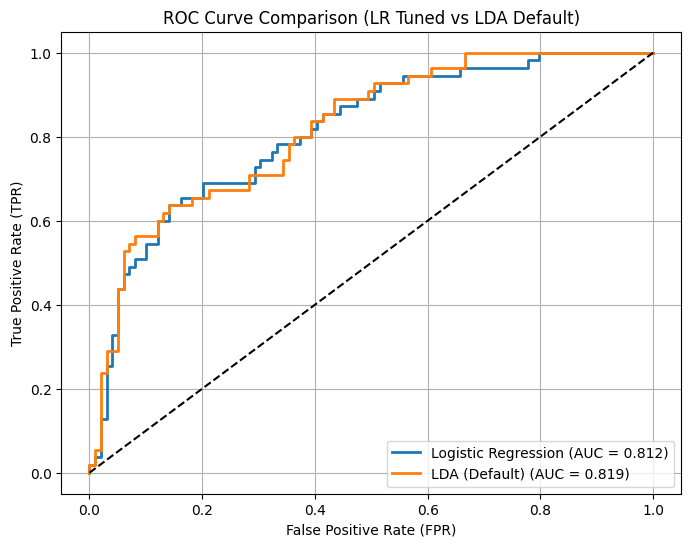

In [33]:
# ===============================
# Define Models Explicitly
# ===============================

# Tuned Logistic Regression
lr_model = LogisticRegression(
    solver="saga",
    penalty="elasticnet",
    C=0.01,
    l1_ratio=0.5,
    max_iter=2000,
    random_state=42
)

# Default LDA (NO hyperparameter tuning)
lda_model = LinearDiscriminantAnalysis()

# Train both models
lr_model.fit(X_train_scaled, y_train)
lda_model.fit(X_train_scaled, y_train)

# ===============================
# ROC Curve Plot
# ===============================
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})", linewidth=2)

# LDA ROC
lda_proba = lda_model.predict_proba(X_test_scaled)[:, 1]
fpr_lda, tpr_lda, _ = roc_curve(y_test, lda_proba)
roc_auc_lda = auc(fpr_lda, tpr_lda)
plt.plot(fpr_lda, tpr_lda, label=f"LDA (Default) (AUC = {roc_auc_lda:.3f})", linewidth=2)

# Random classifier
plt.plot([0, 1], [0, 1], linestyle="--", color="black")

# Formatting
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison (LR Tuned vs LDA Default)")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()


<br>

## **<span style="color:black"> 10. Conclusion  </span>** 


-**Logistic Regression (BEST MODEL)**

| Metric    | Score   |
|-----------|---------|
| Accuracy  | 0.7338  |
| Precision | 0.7917  |
| ROC-AUC   | 0.8121  |


1. Accuracy = 73.4%

- Your model correctly predicts about **7 out of 10 patients**.
- Not bad for a small dataset (1000 rows), but there is room for improvement.

2. Precision = 79.2%

- When your model predicts a patient has diabetes, it is correct almost **8 out of 10 times**.
- High precision is important in medical settings — fewer false positives, so you’re not alarming healthy patients unnecessarily.

3. ROC-AUC = 0.8121

- A score above 0.8 is considered good, meaning your model can distinguish diabetic vs non-diabetic patients quite well.
- Shows strong ranking ability, even if accuracy isn’t perfect.

<br>
<br>

-**Bottom line:**

For a 1000-row dataset, these results are quite reasonable — especially the ROC-AUC > 0.8.
I have achieved good predictive ability while keeping precision high, which is **important in a medical application like diabetes prediction**.
